In [ ]:
# --- Setup Cell ---
# 1. 挂载 Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. 进入你的项目目录
%cd /content/drive/MyDrive/cs336_assignments/assignment1-basics

# 3. 安装依赖 (安装这个 -e . )
!pip install -e .

In [12]:
!pytest -q


tests/test_data.py::test_get_batch PASSED
tests/test_model.py::test_linear PASSED
tests/test_model.py::test_embedding PASSED
tests/test_model.py::test_swiglu PASSED
tests/test_model.py::test_scaled_dot_product_attention PASSED
tests/test_model.py::test_4d_scaled_dot_product_attention PASSED
tests/test_model.py::test_multihead_self_attention PASSED
tests/test_model.py::test_multihead_self_attention_with_rope PASSED
tests/test_model.py::test_transformer_lm PASSED
tests/test_model.py::test_transformer_lm_truncated_input PASSED
tests/test_model.py::test_transformer_block PASSED
tests/test_model.py::test_rmsnorm PASSED
tests/test_model.py::test_rope PASSED
tests/test_model.py::test_silu_matches_pytorch PASSED
tests/test_nn_utils.py::test_softmax_matches_pytorch PASSED
tests/test_nn_utils.py::test_cross_entropy PASSED
tests/test_nn_utils.py::test_gradient_clipping PASSED
tests/test_optimizer.py::test_adamw PASSED
tests/test_optimizer.py::test_get_lr_cosine_schedule PASSED
tests/test_seriali

In [ ]:
%cd /content/drive/MyDrive/cs336_assignments/assignment1-basics

In [ ]:
!python -u cs336_basics/train.py \
  --train-path data/tinystories_train.bin \
  --val-path data/tinystories_valid.bin \
  --vocab-size 10000 \
  --context-length 256 \
  --d-model 512 \
  --num-layers 4 \
  --num-heads 16 \
  --d-ff 1344 \
  --rope-theta 10000 \
  --batch-size 32 \
  --learning-rate 1.5e-3 \
  --beta1 0.9 \
  --beta2 0.95 \
  --eps 1e-8 \
  --weight-decay 0.1 \
  --num-iterations 40000 \
 --checkpoint-path data/no_rmsnorm_lr1p5e-3_checkpoint.pt \
  --checkpoint-interval 5000 \
  --log-interval 100 \
  --val-interval 500 \
  --val-batches 20 \
  --data-dtype uint16 \
  --device cuda \
  --min-learning-rate 1.5e-4 \
  --warmup-iters 4000 \
  --cosine-cycle-iters 40000 \
  --max-l2-norm 1.0 \
  --seed 42 \
  --metrics-path data/no_rmsnorm_lr1p5e-3_metrics.csv

bad columns: ['step', 'train_loss', 'val_loss', 'elapsed_time']
good columns: ['step', 'train_loss', 'val_loss', 'elapsed_time']


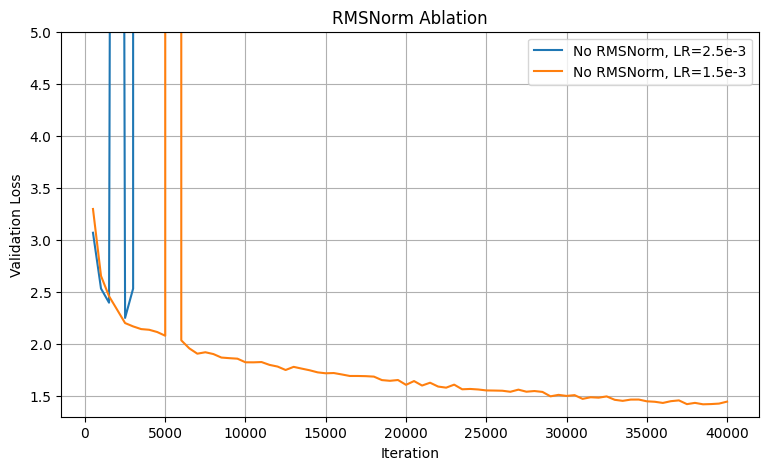

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

bad = pd.read_csv("data/no_rmsnorm_lr2p5e-3_metrics.csv")
good = pd.read_csv("data/no_rmsnorm_lr1p5e-3_metrics.csv")

# 清掉列名可能存在的空格/BOM
bad.columns = bad.columns.str.strip().str.replace("\ufeff", "", regex=False)
good.columns = good.columns.str.strip().str.replace("\ufeff", "", regex=False)

print("bad columns:", bad.columns.tolist())
print("good columns:", good.columns.tolist())

plt.figure(figsize=(9, 5))

plt.plot(
    bad.iloc[:, 0],
    bad["val_loss"],
    label="No RMSNorm, LR=2.5e-3"
)

plt.plot(
    good.iloc[:, 0],
    good["val_loss"],
    label="No RMSNorm, LR=1.5e-3"
)

plt.xlabel("Iteration")
plt.ylabel("Validation Loss")
plt.title("RMSNorm Ablation")
plt.ylim(1.3, 5)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
!python -u cs336_basics/train.py \
  --train-path data/tinystories_train.bin \
  --val-path data/tinystories_valid.bin \
  --vocab-size 10000 \
  --context-length 256 \
  --d-model 512 \
  --num-layers 4 \
  --num-heads 16 \
  --d-ff 1344 \
  --rope-theta 10000 \
  --batch-size 32 \
  --learning-rate 2.5e-3 \
  --beta1 0.9 \
  --beta2 0.95 \
  --eps 1e-8 \
  --weight-decay 0.1 \
  --num-iterations 40000 \
  --checkpoint-path data/post_norm_lr2p5e-3_checkpoint.pt \
  --checkpoint-interval 5000 \
  --log-interval 100 \
  --val-interval 500 \
  --val-batches 20 \
  --data-dtype uint16 \
  --device cuda \
  --min-learning-rate 2.5e-4 \
  --warmup-iters 4000 \
  --cosine-cycle-iters 40000 \
  --max-l2-norm 1.0 \
  --seed 42 \
  --metrics-path data/post_norm_lr2p5e-3_metrics.csv

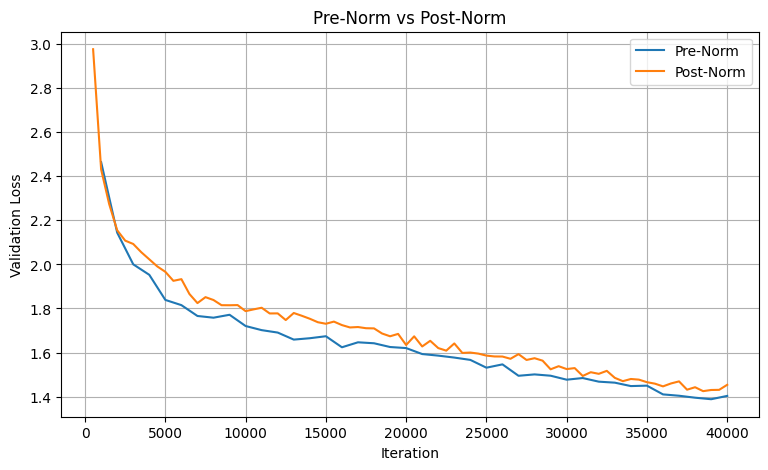

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

pre = pd.read_csv("data/tinystories_final_metrics.csv")
post = pd.read_csv("data/post_norm_lr2p5e-3_metrics.csv")

pre.columns = pre.columns.str.strip()
post.columns = post.columns.str.strip()

plt.figure(figsize=(9, 5))

plt.plot(
    pre["step"],
    pre["val_loss"],
    label="Pre-Norm"
)

plt.plot(
    post["step"],
    post["val_loss"],
    label="Post-Norm"
)

plt.xlabel("Iteration")
plt.ylabel("Validation Loss")
plt.title("Pre-Norm vs Post-Norm")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
%%bash
python -u cs336_basics/train.py \
  --train-path data/tinystories_train.bin \
  --val-path data/tinystories_valid.bin \
  --vocab-size 10000 \
  --context-length 256 \
  --d-model 512 \
  --num-layers 4 \
  --num-heads 16 \
  --d-ff 1344 \
  --rope-theta 10000 \
  --batch-size 32 \
  --learning-rate 2.5e-3 \
  --beta1 0.9 \
  --beta2 0.95 \
  --eps 1e-8 \
  --weight-decay 0.1 \
  --num-iterations 40000 \
  --checkpoint-path data/nope_lr2p5e-3_checkpoint.pt \
  --checkpoint-interval 5000 \
  --log-interval 100 \
  --val-interval 500 \
  --val-batches 20 \
  --data-dtype uint16 \
  --device cuda \
  --min-learning-rate 2.5e-4 \
  --warmup-iters 4000 \
  --cosine-cycle-iters 40000 \
  --max-l2-norm 1.0 \
  --seed 42 \
  --metrics-path data/nope_lr2p5e-3_metrics.csv

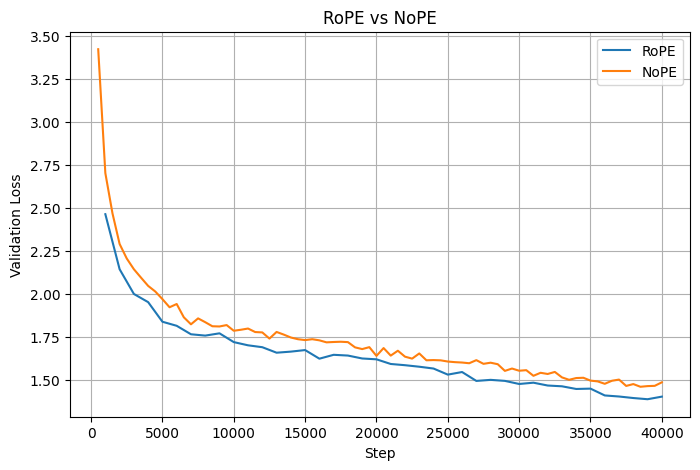

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

rope = pd.read_csv("data/tinystories_final_metrics.csv")
nope = pd.read_csv("data/nope_lr2p5e-3_metrics.csv")

plt.figure(figsize=(8, 5))

plt.plot(
    rope["step"],
    rope["val_loss"],
    label="RoPE"
)

plt.plot(
    nope["step"],
    nope["val_loss"],
    label="NoPE"
)

plt.xlabel("Step")
plt.ylabel("Validation Loss")
plt.title("RoPE vs NoPE")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
!python -u cs336_basics/train.py \
  --train-path data/tinystories_train.bin \
  --val-path data/tinystories_valid.bin \
  --vocab-size 10000 \
  --context-length 256 \
  --d-model 512 \
  --num-layers 4 \
  --num-heads 16 \
  --d-ff 1344 \
  --rope-theta 10000 \
  --batch-size 32 \
  --learning-rate 2.5e-3 \
  --beta1 0.9 \
  --beta2 0.95 \
  --eps 1e-8 \
  --weight-decay 0.1 \
  --num-iterations 40000 \
  --checkpoint-path data/silu_lr2p5e-3_checkpoint.pt \
  --checkpoint-interval 5000 \
  --log-interval 100 \
  --val-interval 500 \
  --val-batches 20 \
  --data-dtype uint16 \
  --device cuda \
  --min-learning-rate 2.5e-4 \
  --warmup-iters 4000 \
  --cosine-cycle-iters 40000 \
  --max-l2-norm 1.0 \
  --seed 42 \
  --metrics-path data/silu_lr2p5e-3_metrics.csv

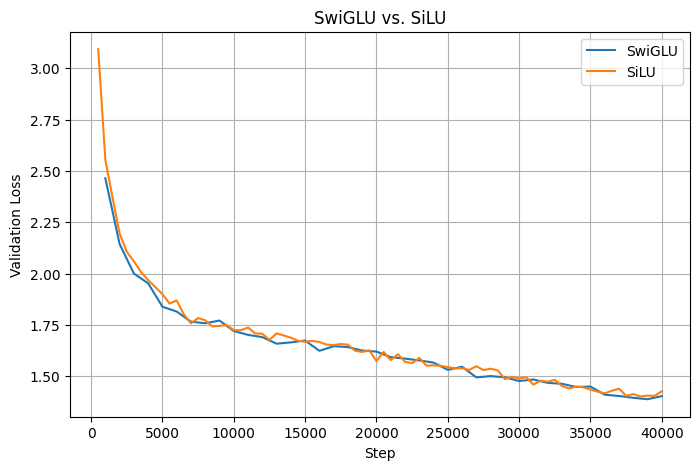

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

swiglu = pd.read_csv("data/tinystories_final_metrics.csv")
silu = pd.read_csv("data/silu_lr2p5e-3_metrics.csv")

plt.figure(figsize=(8, 5))

plt.plot(
    swiglu["step"],
    swiglu["val_loss"],
    label="SwiGLU"
)

plt.plot(
    silu["step"],
    silu["val_loss"],
    label="SiLU"
)

plt.xlabel("Step")
plt.ylabel("Validation Loss")
plt.title("SwiGLU vs. SiLU")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
!python -u cs336_basics/train.py \
  --train-path data/owt_train.bin \
  --val-path data/owt_valid.bin \
  --vocab-size 32000 \
  --context-length 256 \
  --d-model 512 \
  --num-layers 4 \
  --num-heads 16 \
  --d-ff 1344 \
  --rope-theta 10000 \
  --batch-size 32 \
  --learning-rate 2.5e-3 \
  --beta1 0.9 \
  --beta2 0.95 \
  --eps 1e-8 \
  --weight-decay 0.1 \
  --num-iterations 40000 \
  --checkpoint-path data/owt_baseline_checkpoint.pt \
  --checkpoint-interval 5000 \
  --log-interval 100 \
  --val-interval 500 \
  --val-batches 20 \
  --data-dtype uint16 \
  --device cuda \
  --min-learning-rate 2.5e-4 \
  --warmup-iters 4000 \
  --cosine-cycle-iters 40000 \
  --max-l2-norm 1.0 \
  --seed 42 \
  --metrics-path data/owt_baseline_metrics.csv

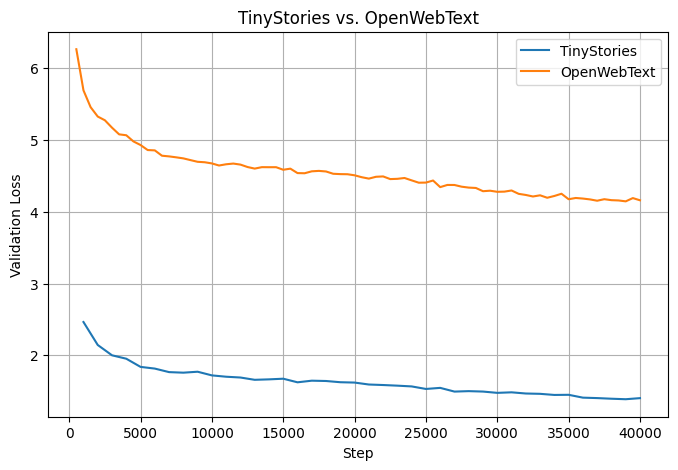

TinyStories final val loss: 1.4031504213809969
OpenWebText final val loss: 4.161174929141998


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

tiny = pd.read_csv("data/tinystories_final_metrics.csv")
owt = pd.read_csv("data/owt_baseline_metrics.csv")

plt.figure(figsize=(8, 5))

plt.plot(
    tiny["step"],
    tiny["val_loss"],
    label="TinyStories"
)

plt.plot(
    owt["step"],
    owt["val_loss"],
    label="OpenWebText"
)

plt.xlabel("Step")
plt.ylabel("Validation Loss")
plt.title("TinyStories vs. OpenWebText")
plt.legend()
plt.grid(True)

plt.show()

print("TinyStories final val loss:", tiny["val_loss"].iloc[-1])
print("OpenWebText final val loss:", owt["val_loss"].iloc[-1])